# Measuring time delays

<a href="mailto:martin.millon@epfl.ch">Martin Millon</a>, 05.2020

PyCS3 offers two estimators, the free-knot splines and regdiff to measure a time delay. 

In [1]:
import sys
#sys.path.append(r'/Users/tpichard/PyCS')
#sys.path.append(r'/Users/jonathan/Library/Python/3.9/lib/python/site-packages')
import pycs3.gen.lc_func
import pycs3.csvconvert
#import pycs3.curvestest
from pycs3.gen.lc import LightCurve
import pycs3.spl.topopt
import pycs3.gen.mrg
import pycs3.gen.splml
import pycs3.regdiff.multiopt
import pycs3.regdiff.rslc
import numpy as np
import logging
loggerformat='%(message)s'
logging.basicConfig(format=loggerformat,level=logging.INFO)

In [4]:
# NEW
# csvgaia="~/GAIA/PyCS3/notebook/data/liste_Jonathan.csv"
#csvgaia="~/GAIA/PyCS3/notebook/data/new_dgdreq71.csv"
csvgaia="data/dgdreq2025nov21_JB.csv"
# csvgaia="~/GAIA/PyCS3/notebook/data/test.csv"
pycs3.csvconvert.conversion_gaia_pycs3(csvgaia,magconvert=True)
#curves=pycs3.csvconvert.load_lcs(source_ids=(None), mode='exclusion')      #does all in file
# 517452083... (J0247-2646) no obvious TD
# curves=pycs3.csvconvert.load_lcs(source_ids=([5077935264216200832]), mode='inclusion')    #  WGD0259-2338
# curves=pycs3.csvconvert.load_lcs(source_ids=([2216740927658907648]), mode='inclusion')   #  J2145+6345
# curves=pycs3.csvconvert.load_lcs(source_ids=([1910735807875873664]), mode='inclusion')  #  J2308+3201
# curves=pycs3.csvconvert.load_lcs(source_ids=([2623596445097415040]), mode='inclusion')  # GRAL224411340-05504960
# curves=pycs3.csvconvert.load_lcs(source_ids=([395754921063313024]), mode='inclusion')    #  J0013+5119A
# curves=pycs3.csvconvert.load_lcs(source_ids=([380075812236197760]), mode='inclusion')    #  GraLJ002134.91+39290
# curves=pycs3.csvconvert.load_lcs(source_ids=([2348420123825646336]), mode='inclusion')    #  WGA0030-2326A
# curves=pycs3.csvconvert.load_lcs(source_ids=([2373803788569100160]), mode='inclusion')    #  J0030-1525A
# curves=pycs3.csvconvert.load_lcs(source_ids=([4999447421238071936]), mode='inclusion')    #  J0045-3937A - single - look for comp A
# curves=pycs3.csvconvert.load_lcs(source_ids=([2369490546185699328]), mode='inclusion')    #  HE0047-1756A
# curves=pycs3.csvconvert.load_lcs(source_ids=([2355800355108946432]), mode='inclusion')    #  DESJ0053-2012A no plot
# curves=pycs3.csvconvert.load_lcs(source_ids=([2371361983695995264]), mode='inclusion')    #  GraLJ005717.08-15515
# curves=pycs3.csvconvert.load_lcs(source_ids=([2804295954148390272]), mode='inclusion')    #  J0102+2445A
# curves=pycs3.csvconvert.load_lcs(source_ids=([2358531232755701504]), mode='inclusion')    #  DESJ0112-1650A single
# curves=pycs3.csvconvert.load_lcs(source_ids=([2531819311878644096]), mode='inclusion')    #  GraLJ011323.55-02263
# curves=pycs3.csvconvert.load_lcs(source_ids=([4915503625466318464]), mode='inclusion')    #  DESJ0115-5244A  single
# curves=pycs3.csvconvert.load_lcs(source_ids=([372057559265314688]), mode='inclusion')    #  J0116+4052A
# curves=pycs3.csvconvert.load_lcs(source_ids=([2533897461870477568]), mode='inclusion')    #  J0124-0033A single
# curves=pycs3.csvconvert.load_lcs(source_ids=([322056271561143680]), mode='inclusion')    #  GraLJ013145.05+36241
# curves=pycs3.csvconvert.load_lcs(source_ids=([291933776127888768]), mode='inclusion')    #  GraLJ013458.94+24304
# curves=pycs3.csvconvert.load_lcs(source_ids=([2561983348235519360]), mode='inclusion')    #  GraLJ013535.55+05522
# curves=pycs3.csvconvert.load_lcs(source_ids=([318810027903595392]), mode='inclusion')    #  GraLJ013933.37+35261
# curves=pycs3.csvconvert.load_lcs(source_ids=([2457482365811994368]), mode='inclusion')    #  J0140-1152A
# curves=pycs3.csvconvert.load_lcs(source_ids=([2464353660650971520]), mode='inclusion')    #  Q0142-100A
# curves=pycs3.csvconvert.load_lcs(source_ids=([2460545948804796032]), mode='inclusion')    #  WGA0146-1133A  ************************
# curves=pycs3.csvconvert.load_lcs(source_ids=([350937280929196928]), mode='inclusion')    #  2MASXJ01471020+46304
# curves=pycs3.csvconvert.load_lcs(source_ids=([4954121596274054400]), mode='inclusion')    #  GraLJ0147-4657A
# curves=pycs3.csvconvert.load_lcs(source_ids=([4960819894125714944]), mode='inclusion')    #  DESJ0150-4041A
# curves=pycs3.csvconvert.load_lcs(source_ids=([5026013408869280128]), mode='inclusion')    #  J0152-2448A
# curves=pycs3.csvconvert.load_lcs(source_ids=([4955044292688756224]), mode='inclusion')    #  GraLJ0154-4402A
# curves=pycs3.csvconvert.load_lcs(source_ids=([5024429528010102144]), mode='inclusion')    #  J0156-2751A
# curves=pycs3.csvconvert.load_lcs(source_ids=([4956574748452174592]), mode='inclusion')    #  QJ0158-4325A
# curves=pycs3.csvconvert.load_lcs(source_ids=([5148785186464567168]), mode='inclusion')    #  J0200-1509A
# curves=pycs3.csvconvert.load_lcs(source_ids=([4956634220861679360]), mode='inclusion')    #  GraLJ0202-4319A
# curves=pycs3.csvconvert.load_lcs(source_ids=([76904623545392512]), mode='inclusion')    #  GraLJ0202+1317A
# curves=pycs3.csvconvert.load_lcs(source_ids=([4971233295737205760]), mode='inclusion')    #  GraLJ0205-3233A
# curves=pycs3.csvconvert.load_lcs(source_ids=([4964421000864875904]), mode='inclusion')    #  J0209-3841A
# curves=pycs3.csvconvert.load_lcs(source_ids=([5124658637175794048]), mode='inclusion')    #  WG0214-2105A
# curves=pycs3.csvconvert.load_lcs(source_ids=([4643616493228910080]), mode='inclusion')    #  OGLEJ021812.34-73353
# curves=pycs3.csvconvert.load_lcs(source_ids=([337933769222851840]), mode='inclusion')    #  J0228+3953A
# curves=pycs3.csvconvert.load_lcs(source_ids=([2515417110948750976]), mode='inclusion')    #  GraLJ0229+0320A
# curves=pycs3.csvconvert.load_lcs(source_ids=([5119328548401927936]), mode='inclusion')    #  J0232-2429A
# curves=pycs3.csvconvert.load_lcs(source_ids=([5119104866505106688]), mode='inclusion')    #  J0235-2433A
# curves=pycs3.csvconvert.load_lcs(source_ids=([5184007624848431872]), mode='inclusion')    #  DESJ0245-0556A
# curves=pycs3.csvconvert.load_lcs(source_ids=([5174409201871203584]), mode='inclusion')    #  SDSS0246-0825A
# curves=pycs3.csvconvert.load_lcs(source_ids=([549281756875772672]), mode='inclusion')    #  J0247+7706A
# curves=pycs3.csvconvert.load_lcs(source_ids=([5075630859644356480]), mode='inclusion')    #  J0247-0800A   single
# curves=pycs3.csvconvert.load_lcs(source_ids=([5174520836660663296]), mode='inclusion')    #  J0247-2646A
# curves=pycs3.csvconvert.load_lcs(source_ids=([83871575896093312]), mode='inclusion')    #  GraLJ024848742+19133
# curves=pycs3.csvconvert.load_lcs(source_ids=([114294031844958720]), mode='inclusion')    #  GraLJ024859.50+24593
# curves=pycs3.csvconvert.load_lcs(source_ids=([5153686358329651840]), mode='inclusion')    #  GraLJ025359.90-16394
# curves=pycs3.csvconvert.load_lcs(source_ids=([5077935264216200832]), mode='inclusion')    #  WGD0259-2338A
# curves=pycs3.csvconvert.load_lcs(source_ids=([5153828508862119040]), mode='inclusion')    #  WISE025942.9-163543A
# curves=pycs3.csvconvert.load_lcs(source_ids=([5098921578230761472]), mode='inclusion')    #  J0325-2232A
# curves=pycs3.csvconvert.load_lcs(source_ids=([3261414236903292160]), mode='inclusion')    #  GraLJ032942.76-02081
# curves=pycs3.csvconvert.load_lcs(source_ids=([4674636224510336256]), mode='inclusion')    #  J0339-6121A
# curves=pycs3.csvconvert.load_lcs(source_ids=([5085135764002995584]), mode='inclusion')    #  DESJ0340-2545B
# curves=pycs3.csvconvert.load_lcs(source_ids=([63971411866955904]), mode='inclusion')    #  GraLJ034611.0+215444
# curves=pycs3.csvconvert.load_lcs(source_ids=([4672765852152430848]), mode='inclusion')    #  J0346-6414A  single
# curves=pycs3.csvconvert.load_lcs(source_ids=([5087747928752251776]), mode='inclusion')    #  J0347-2154A
# curves=pycs3.csvconvert.load_lcs(source_ids=([4834883855209175296]), mode='inclusion')    #  J0350-4611A
# curves=pycs3.csvconvert.load_lcs(source_ids=([4683151559814721920]), mode='inclusion')    #  J0355-5624A single
# curves=pycs3.csvconvert.load_lcs(source_ids=([5082980996090316800]), mode='inclusion')    #  J0401-2514A
# curves=pycs3.csvconvert.load_lcs(source_ids=([4842045799074927232]), mode='inclusion')    #  DESJ0402-4220A  single
# curves=pycs3.csvconvert.load_lcs(source_ids=([4845606606136183424]), mode='inclusion')    #  J0405-3730A
# curves=pycs3.csvconvert.load_lcs(source_ids=([4883180423150691584]), mode='inclusion')    #  DESJ040559.80-330851
# curves=pycs3.csvconvert.load_lcs(source_ids=([4830236636170244480]), mode='inclusion')    #  DESJ040710.22-500600
# curves=pycs3.csvconvert.load_lcs(source_ids=([4779902849277205760]), mode='inclusion')    #  J0408-5354A
# curves=pycs3.csvconvert.load_lcs(source_ids=([4778637895508914048]), mode='inclusion')    #  J0416-5606A
# curves=pycs3.csvconvert.load_lcs(source_ids=([175720825910626304]), mode='inclusion')    #  J0417+3325A
# curves=pycs3.csvconvert.load_lcs(source_ids=([3178020716638059264]), mode='inclusion')    #  HE0435-1223A
# curves=pycs3.csvconvert.load_lcs(source_ids=([3185808420059318016]), mode='inclusion')    #  J0440-0905A
# curves=pycs3.csvconvert.load_lcs(source_ids=([4894145268500809728]), mode='inclusion')    #  GraLJ044355.21-24032
# curves=pycs3.csvconvert.load_lcs(source_ids=([4877987734675447936]), mode='inclusion')    #  GraLJ0446-3102A
# curves=pycs3.csvconvert.load_lcs(source_ids=([4624301922220808832]), mode='inclusion')    #  J0457-7820A
curves=pycs3.csvconvert.load_lcs(source_ids=([3187010529866092672]), mode='inclusion')    #  J050129.5-073309A
# curves=pycs3.csvconvert.load_lcs(source_ids=([4813484648808076544]), mode='inclusion')    #  DESJ0501-4118A
# curves=pycs3.csvconvert.load_lcs(source_ids=([4770993403477832064]), mode='inclusion')    #  GraLJ0503-5304A
# curves=pycs3.csvconvert.load_lcs(source_ids=([2959785663027256832]), mode='inclusion')    #  J0504-2446A
# curves=pycs3.csvconvert.load_lcs(source_ids=([2959142032112859264]), mode='inclusion')    #  GraLJ0506-2530A
# curves=pycs3.csvconvert.load_lcs(source_ids=([4826116113268202112]), mode='inclusion')    #  HE0512-3329A
# curves=pycs3.csvconvert.load_lcs(source_ids=([4807486087029366784]), mode='inclusion')    #  J0526-3933A
# curves=pycs3.csvconvert.load_lcs(source_ids=([196343055547397888]), mode='inclusion')    #  J0544+4350A
# curves=pycs3.csvconvert.load_lcs(source_ids=([2903556569666059648]), mode='inclusion')    #  GraLJ055403.56-29544
# curves=pycs3.csvconvert.load_lcs(source_ids=([2966721824756464896]), mode='inclusion')    #  GraLJ055502.44-18332
# curves=pycs3.csvconvert.load_lcs(source_ids=([2903331715240526592]), mode='inclusion')    #  PSJ0557-2959A
# curves=pycs3.csvconvert.load_lcs(source_ids=([5571267199383508096]), mode='inclusion')    #  DESJ0602-4335A
# curves=pycs3.csvconvert.load_lcs(source_ids=([2916884609097868672]), mode='inclusion')    #  GraLJ060710.8-215217
# curves=pycs3.csvconvert.load_lcs(source_ids=([960989934527118848]), mode='inclusion')    #  GraLJ060841.4+422937
# curves=pycs3.csvconvert.load_lcs(source_ids=([1116767058322038656]), mode='inclusion')    #  GraLJ061615.591+7714
# curves=pycs3.csvconvert.load_lcs(source_ids=([5261791097486778624]), mode='inclusion')    #  J0628-7448A
# curves=pycs3.csvconvert.load_lcs(source_ids=([3000185396729743104]), mode='inclusion')    #  J0630-1201A
# curves=pycs3.csvconvert.load_lcs(source_ids=([1103603357219723904]), mode='inclusion')    #  J0635+6452A       single
# curves=pycs3.csvconvert.load_lcs(source_ids=([3385786701564912384]), mode='inclusion')    #  J0643+2725A
# curves=pycs3.csvconvert.load_lcs(source_ids=([2933340793481678208]), mode='inclusion')    #  GraLJ064544.07-19293   single
# curves=pycs3.csvconvert.load_lcs(source_ids=([3361094865862486656]), mode='inclusion')    #  GraLJ065904.1+162909
# curves=pycs3.csvconvert.load_lcs(source_ids=([986525370526178176]), mode='inclusion')    #  GraLJ071943+525553A
# curves=pycs3.csvconvert.load_lcs(source_ids=([5585883698943303296]), mode='inclusion')    #  GraLJ0722425-390159A
# curves=pycs3.csvconvert.load_lcs(source_ids=([871794729486078336]), mode='inclusion')    #  GraLJ072827.74+26070
# curves=pycs3.csvconvert.load_lcs(source_ids=([672293537240480768]), mode='inclusion')    #  J0734+1915A
# curves=pycs3.csvconvert.load_lcs(source_ids=([3138952727746236800]), mode='inclusion')    #  J0740+0635A
# curves=pycs3.csvconvert.load_lcs(source_ids=([867913659598182272]), mode='inclusion')    #  SDSSJ0743+2457A  single
# curves=pycs3.csvconvert.load_lcs(source_ids=([3164374261215669888]), mode='inclusion')    #  DESIJ0746+1344A
# curves=pycs3.csvconvert.load_lcs(source_ids=([925907232901783296]), mode='inclusion')    #  SDSS0746+4403A
# curves=pycs3.csvconvert.load_lcs(source_ids=([921013100488801920]), mode='inclusion')    #  J0803+3908A         single
# curves=pycs3.csvconvert.load_lcs(source_ids=([670520540382618496]), mode='inclusion')    #  SDSS0806+2006A
# curves=pycs3.csvconvert.load_lcs(source_ids=([5694395291770945280]), mode='inclusion')    #  GraLJ081828.3-261325
# curves=pycs3.csvconvert.load_lcs(source_ids=([3097346657995436800]), mode='inclusion')    #  SDSSJ0820+0812A
# curves=pycs3.csvconvert.load_lcs(source_ids=([649514817411198976]), mode='inclusion')    #  HS0818+1227A   single
# curves=pycs3.csvconvert.load_lcs(source_ids=([679072919780579200]), mode='inclusion')    #  SDSSJ0823+2418A   
# curves=pycs3.csvconvert.load_lcs(source_ids=([1097468636388676608]), mode='inclusion')    #  J0826+7002A
# curves=pycs3.csvconvert.load_lcs(source_ids=([3092314541167221760]), mode='inclusion')    #  SDSSJ0832+0404A
# curves=pycs3.csvconvert.load_lcs(source_ids=([3080259323881652608]), mode='inclusion')    #  J0833+0331A           single
# curves=pycs3.csvconvert.load_lcs(source_ids=([5643847512428416384]), mode='inclusion')    #  J0834-2933A
# curves=pycs3.csvconvert.load_lcs(source_ids=([5641500188236488704]), mode='inclusion')    #  GraLJ0859-3011A
# curves=pycs3.csvconvert.load_lcs(source_ids=([1016218227493362816]), mode='inclusion')    #  SDSS0903+5028A      single
# curves=pycs3.csvconvert.load_lcs(source_ids=([607381016436338560]), mode='inclusion')    #  SDSSJ0904+1512A
# curves=pycs3.csvconvert.load_lcs(source_ids=([712654684950723072]), mode='inclusion')    #  J0904+3343A
# curves=pycs3.csvconvert.load_lcs(source_ids=([3842934499335828608]), mode='inclusion')    #  GraLJ090710.5+000321
# curves=pycs3.csvconvert.load_lcs(source_ids=([1043171896055716608]), mode='inclusion')    #  GraLJ090751.71+62244
# curves=pycs3.csvconvert.load_lcs(source_ids=([580537092879961472]), mode='inclusion')    #  RXJ0911+0551A     mixture of sources
# curves=pycs3.csvconvert.load_lcs(source_ids=([1022663637669586176]), mode='inclusion')    #  SBS0909+532A
# curves=pycs3.csvconvert.load_lcs(source_ids=([698878899471973120]), mode='inclusion')    #  J0921+3020A           single
# curves=pycs3.csvconvert.load_lcs(source_ids=([695593902327484544]), mode='inclusion')    #  SDSSJ0921+2854A
# curves=pycs3.csvconvert.load_lcs(source_ids=([817452844753700736]), mode='inclusion')    #  J0924+4235A                single
# curves=pycs3.csvconvert.load_lcs(source_ids=([3844748070752040576]), mode='inclusion')    #  SDSS0924+0219A
# curves=pycs3.csvconvert.load_lcs(source_ids=([817592276569391488]), mode='inclusion')    #  GraLJ092836.85+43273       single
# curves=pycs3.csvconvert.load_lcs(source_ids=([5691734916002651136]), mode='inclusion')    #  J0936-1211A
#
# curves=pycs3.csvconvert.load_lcs(source_ids=([1026420252290292480]), mode='inclusion')    #  J0937+5835A
# curves=pycs3.csvconvert.load_lcs(source_ids=([3851608129957910400]), mode='inclusion')    #  J0941+0518A
# curves=pycs3.csvconvert.load_lcs(source_ids=([641511742854886144]), mode='inclusion')    #  GraLJ094235.00+23103
# curves=pycs3.csvconvert.load_lcs(source_ids=([613773504026183808]), mode='inclusion')    #  GraLJ094248.49+11490
# curves=pycs3.csvconvert.load_lcs(source_ids=([621369175165121408]), mode='inclusion')    #  SDSSJ0946+1835A       single
# curves=pycs3.csvconvert.load_lcs(source_ids=([797882950824323584]), mode='inclusion')    #  J0943+3532A
# curves=pycs3.csvconvert.load_lcs(source_ids=([807714470266431488]), mode='inclusion')    #  J0949+4208A
# curves=pycs3.csvconvert.load_lcs(source_ids=([646884373280519936]), mode='inclusion')    #  FBQ0951+2635A
# curves=pycs3.csvconvert.load_lcs(source_ids=([5672017928032611840]), mode='inclusion')    #  GraLJ095402.82-18291
# curves=pycs3.csvconvert.load_lcs(source_ids=([5687124801186026880]), mode='inclusion')    #  J0954-1421A
# curves=pycs3.csvconvert.load_lcs(source_ids=([3832692033126977664]), mode='inclusion')    #  BRI0952-0115A    single
# curves=pycs3.csvconvert.load_lcs(source_ids=([1045166002126206720]), mode='inclusion')    #  Q0957+561A
# curves=pycs3.csvconvert.load_lcs(source_ids=([827031141513223936]), mode='inclusion')    #  SDSS1001+5027A
# curves=pycs3.csvconvert.load_lcs(source_ids=([806853178999388928]), mode='inclusion')    #  SDSS1004+4112A
# curves=pycs3.csvconvert.load_lcs(source_ids=([3834882054131088512]), mode='inclusion')    #  J1008+0046A       NIDB  single
# curves=pycs3.csvconvert.load_lcs(source_ids=([3876832198007366912]), mode='inclusion')    #  J1008+0929A
# curves=pycs3.csvconvert.load_lcs(source_ids=([5666444778469974656]), mode='inclusion')    #  GraLJ1008-2215A  
# curves=pycs3.csvconvert.load_lcs(source_ids=([730552393494441856]), mode='inclusion')    #  SDSSJ105440.83+27330
# curves=pycs3.csvconvert.load_lcs(source_ids=([3552950883176150016]), mode='inclusion')    #  HE1104-1805A
# curves=pycs3.csvconvert.load_lcs(source_ids=([3817878828362669568]), mode='inclusion')    #  PG1115+080A
# curves=pycs3.csvconvert.load_lcs(source_ids=([3541826024524572544]), mode='inclusion')    #  2MASSJ11344050-21032
# curves=pycs3.csvconvert.load_lcs(source_ids=([1537658249711963904]), mode='inclusion')    #  SDSS1206+4332A
# curves=pycs3.csvconvert.load_lcs(source_ids=([6159550763996866944]), mode='inclusion')    #  J1247-3253A
# curves=pycs3.csvconvert.load_lcs(source_ids=([3941492797505654784]), mode='inclusion')    #  SDSSJ130443.58+20010
# curves=pycs3.csvconvert.load_lcs(source_ids=([3511426761399556352]), mode='inclusion')    #  2MASSJ13102005-17145
# curves=pycs3.csvconvert.load_lcs(source_ids=([3733119018870073216]), mode='inclusion')    #  SDSSJ1322+1052A
# curves=pycs3.csvconvert.load_lcs(source_ids=([1475457506834977280]), mode='inclusion')    #  SDSSJ1330+3800A
# curves=pycs3.csvconvert.load_lcs(source_ids=([1469230594530741760]), mode='inclusion')    #  SDSSJ1334+3315A
# curves=pycs3.csvconvert.load_lcs(source_ids=([3711531005707407104]), mode='inclusion')    #  SDSSJ1335+0118A
# curves=pycs3.csvconvert.load_lcs(source_ids=([3728132222538228864]), mode='inclusion')    #  SDSSJ134859.31+12265
# curves=pycs3.csvconvert.load_lcs(source_ids=([1454504418686043904]), mode='inclusion')    #  J1400+3134A
# curves=pycs3.csvconvert.load_lcs(source_ids=([1599341745383363328]), mode='inclusion')    #  SBS1520+530A


⚠️ Trop peu de points pour la composante 76904623545392579 de la source 76904623545392512.
⚠️ Trop peu de points pour la composante 76904623545392581 de la source 76904623545392512.
⚠️ Trop peu de points pour la composante 76904623545392583 de la source 76904623545392512.
⚠️ Trop peu de points pour la composante 76904623545392585 de la source 76904623545392512.
⚠️ Source 78702389482720512 ignorée (une seule composante).
⚠️ Trop peu de points pour la composante 83871575895472839 de la source 83871575895472768.
⚠️ Trop peu de points pour la composante 83871575895472841 de la source 83871575895472768.
⚠️ Trop peu de points pour la composante 83871575895472843 de la source 83871575895472768.
⚠️ Trop peu de points pour la composante 291933771834449861 de la source 291933771834449792.
⚠️ Trop peu de points pour la composante 318810027903595461 de la source 318810027903595392.
⚠️ Source 328069053976561536 ignorée (une seule composante).
⚠️ Source 337933769222851840 ignorée (une seule composan

Checking header of "3187010529866092672_component_A.txt"...
Reading "3187010529866092672_component_A.txt"...
[Unknown/A] with 102 points imported (0 of them masked).
Checking header of "3187010529866092672_component_B.txt"...
Reading "3187010529866092672_component_B.txt"...
[Unknown/B] with 100 points imported (0 of them masked).


⚠️ Trop peu de points pour la composante 6681326549578891849 de la source 6681326549578891776.
⚠️ Trop peu de points pour la composante 6681326549578891851 de la source 6681326549578891776.
⚠️ Trop peu de points pour la composante 6752010028962613955 de la source 6752010028962613888.
⚠️ Trop peu de points pour la composante 6775750615307601729 de la source 6775750615307601664.
⚠️ Trop peu de points pour la composante 6775750615307601731 de la source 6775750615307601664.
⚠️ Trop peu de points pour la composante 6775750615307601733 de la source 6775750615307601664.
⚠️ Trop peu de points pour la composante 6884039075985949123 de la source 6884039075985949056.
⚠️ Trop peu de points pour la composante 6884039075985949125 de la source 6884039075985949056.
⚠️ Trop peu de points pour la composante 6884039075985949127 de la source 6884039075985949056.
⚠️ Trop peu de points pour la composante 6897592820245635395 de la source 6897592820245635328.
✅ 645 fichiers exportés dans le dossier : C:\Users

In [3]:
#rdbfile = "/Users/jonathan/GAIA/PyCS3/notebook/data/trialcurves.txt"

#lcs = [
#    pycs3.gen.lc_func.rdbimport(rdbfile, 'A', 'mag_A', 'magerr_A', "Trial"),
#    pycs3.gen.lc_func.rdbimport(rdbfile, 'B', 'mag_B', 'magerr_B', "Trial"),
#    pycs3.gen.lc_func.rdbimport(rdbfile, 'C', 'mag_C', 'magerr_C', "Trial"),
#    pycs3.gen.lc_func.rdbimport(rdbfile, 'D', 'mag_D', 'magerr_D', "Trial")
#]
#pycs3.gen.mrg.colourise(lcs) # Gives each curve a different colour.

- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - 
	[Unknown/A]
102 points (total), 0 of which are masked
12 seasons (gap: >60), gap length : 113.9 +/- 31.0 days
Sampling : median 0.2, mean 7.7, max 54.2, min 0.07 days
Shifts : (0.00000,0.00000,0.00) [days, mag, flux]
Colour : darkorange
Common properties : 
   All properties : 
Comments :
   Imported from 3187010529866092672_component_A.txt, columns (3, 4, 5)
- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - 


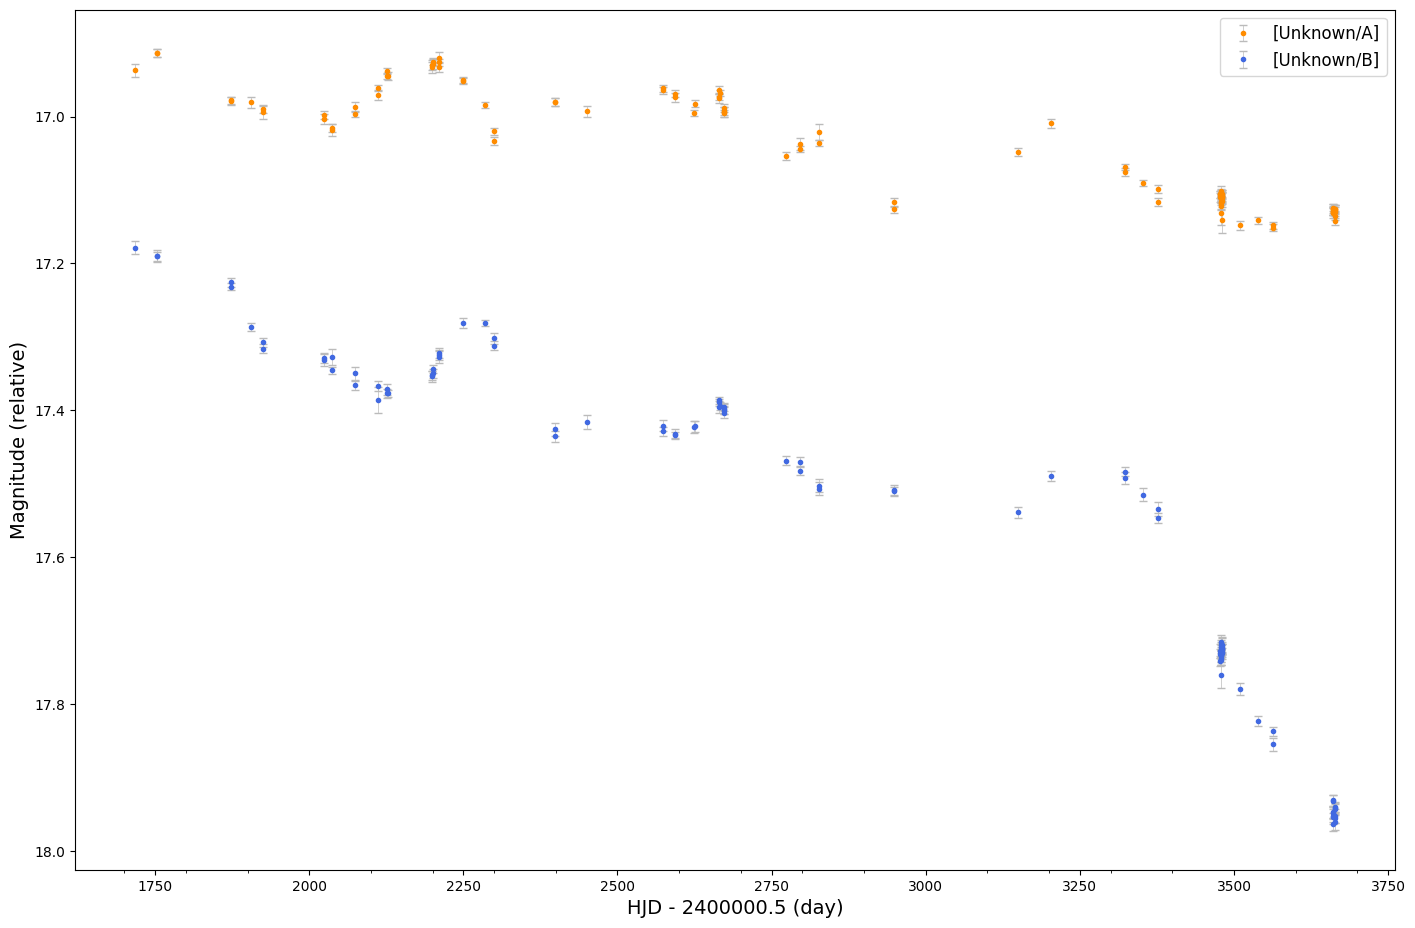

In [8]:
%matplotlib inline
for source,lcs in curves.items():
    print(lcs[0].longinfo())
    pycs3.gen.mrg.colourise(lcs) # Gives each curve a different colour.
    pycs3.gen.lc_func.display(lcs, figsize= (15,10)) 

## Spline 
PyCS3 will model the intrinsic variability that is shared between the light curves with a single free-knot spline. It will also optmise the time delays between curves. The key parameter to control the smoothness of the fit is `knotstep`. It corresponds to the mean spacing between knots before starting the optimisation.

First, the optimising function needs to be defined. We go first for a rough estimation of the time-delay and we then refine it with the `opt_fine` function. If you shift the curves manually, and start the fit from a value that is <10 days from the true delay, running `opt_fine` only is sufficient. 

Starting ML optimization ...
Done !


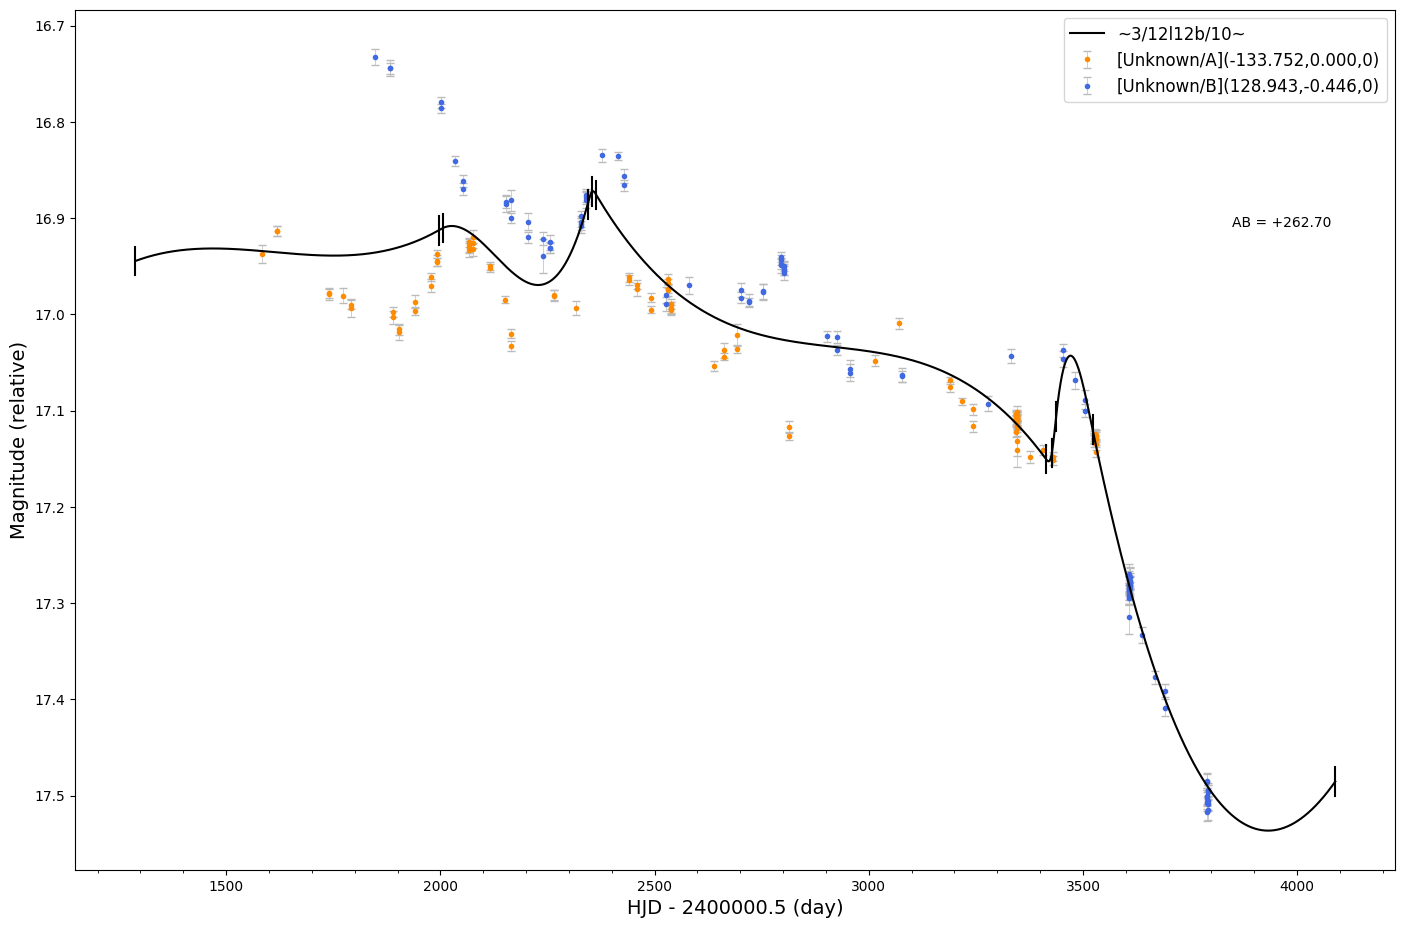

- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - 
	[Unknown/A](-133.752,0.000,0)
102 points (total), 0 of which are masked
12 seasons (gap: >60), gap length : 113.9 +/- 31.0 days
Sampling : median 0.2, mean 7.7, max 54.2, min 0.07 days
Shifts : (-133.75213,0.00000,0.00) [days, mag, flux]
Colour : darkorange
Common properties : 
   All properties : 
Comments :
   Imported from 3187010529866092672_component_A.txt, columns (3, 4, 5)
- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - 
Time delays:
AB = +262.70


In [9]:
def spl(lcs):
    spline = pycs3.spl.topopt.opt_rough(lcs, nit=5, knotstep=350, verbose=False)  #knotstep a modifier selon echantillonage
    spline = pycs3.spl.topopt.opt_fine(lcs, nit=10, knotstep=240, verbose=False)  #a modifier selon echantillonage
#    spline = pycs3.spl.topopt.opt_rough(lcs, nit=5, knotstep=150, verbose=False)  #knotstep a modifier selon echantillonage
#    spline = pycs3.spl.topopt.opt_fine(lcs, nit=10, knotstep=140, verbose=False)  #a modifier selon echantillonage
    return spline

for source,lcs in curves.items():
    spline = spl(lcs)
#%matplotlib inline
    pycs3.gen.lc_func.display(lcs, [spline], figsize = (15,10), showdelays =True)
    print(lcs[0].longinfo())
    print ("Time delays:")
    print (pycs3.gen.lc_func.getnicetimedelays(lcs, separator="\n", to_be_sorted=True))

# ATTN il garde des infos -- donc soit reset soit tout refaire tourner

This is a pretty poor fit... This is because the curves are affected by extrinsic variation (e.g., microlensing). We need to account for this by introducing a microlensing model. 


### Adding spline microlensing 
We can now attach a spline to each light curves to model extrinsic variability with splines. Choose a knotstep larger than the knotstep of the intrinsic spline to ensure that the microlensing model is not too degenerate with the intrinsic model. 

Starting ML optimization ...
Working on the spline ML of [Unknown/A](-133.752,0.000,0)|~3/u/2~|
Working on the spline ML of [Unknown/B](128.943,-0.446,0)|~3/u/2~|
Done !


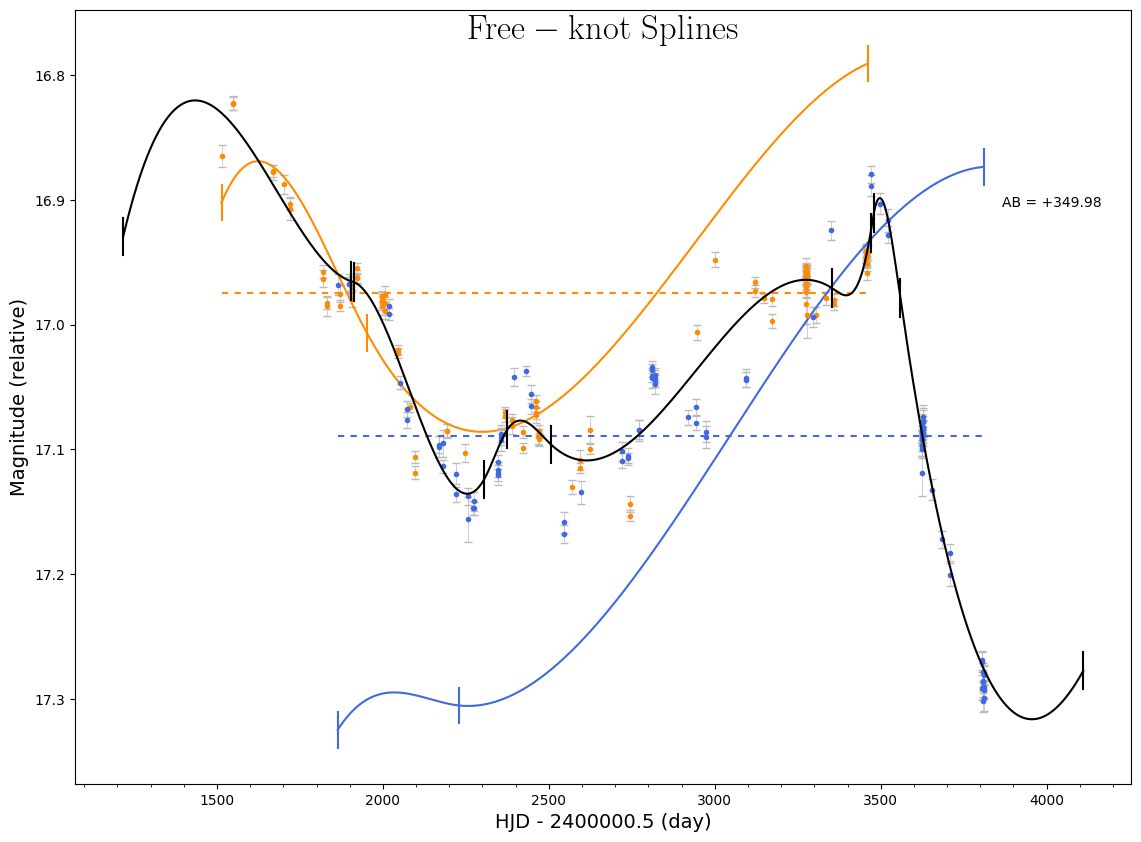

Time delays:
AB = +349.98


In [10]:
mlknotstep = 500   #knotstep a modifier selon echantillonage

for source,lcs in curves.items():
    for lc in lcs : 
        pycs3.gen.splml.addtolc(lc, knotstep=mlknotstep) #we attach microlensing to the LightCurve object
    spline = spl(lcs)
    pycs3.gen.lc_func.display(lcs, [spline], figsize = (12,9), showdelays =True, 
                          showlegend =False, title=r"$\mathrm{Free-knot\ Splines }$")
    print ("Time delays:")
    print (pycs3.gen.lc_func.getnicetimedelays(lcs, separator="\n", to_be_sorted=True))

This is now much better and we recover time delays close to the correct "true" delays : $\Delta t_{AB}$ = -5 days, $\Delta t_{AC}$ = -20 days and $\Delta t_{AD}$ = -70 days 

### Adding polynomial microlensing 
PyCS3 also offer the possibility to model the extrinsic variability with polynomials. To demonstrate the flexibility of PyCS3, we will add : 
- polynomial microlensing of degree 1, to each season of the B curves
- polynomial microlensing of degree 2 on the entire monitoring campaign for the C light curve
- polynomial microlensing of degree 2 on the entire monitoring campaign for the D light curve


Starting ML optimization ...
Working on the poly ML of [Unknown/B](0.000,-0.446,0)|poly/3|
Done !


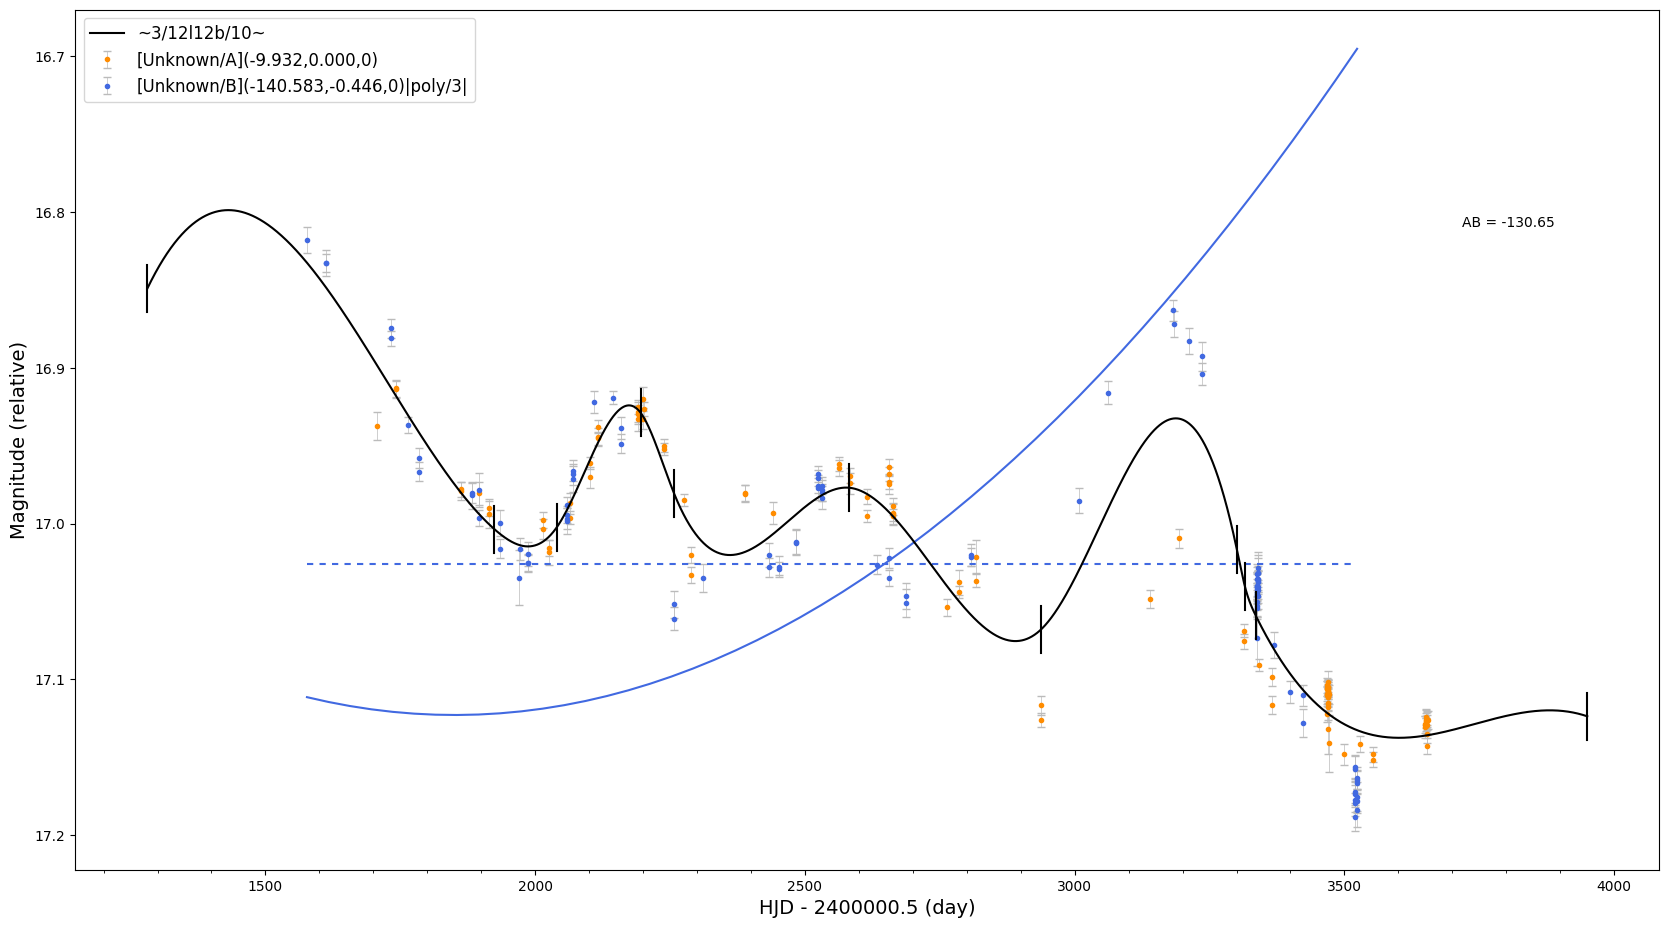

Time delays:
AB = -130.65


In [11]:
for source,lcs in curves.items():
    for lc in lcs : 
        lc.resetshifts() #We reset the time shift, magnitude shift and remove microlensing    

#pycs3.gen.lc_func.applyshifts(lcs, [0.,0.,-10.,-60.], [0.,0.,0.,0.]) # we had an initial guess of the time delay
#JB line above is just for their lens
    
#we now add polynomial microlensing to the curves
for source,lcs in curves.items():
    pycs3.gen.polyml.addtolc(lcs[1], nparams=3, autoseasonsgap=300.0)  # add affine microlensing to each season
#JB specifique a leur lentille.  uniquement lcs[1] pour un double    
#pycs3.gen.polyml.addtolc(lcs[2], nparams=3, autoseasonsgap=600.0)  # add polynomial of degree 2 on the entire light curve
#pycs3.gen.polyml.addtolc(lcs[3], nparams=4, autoseasonsgap=600.0)

    spline = spl(lcs)
    pycs3.gen.lc_func.display(lcs, [spline], figsize = (18,10), showdelays =True)
    print ("Time delays:")
    print (pycs3.gen.lc_func.getnicetimedelays(lcs, separator="\n", to_be_sorted=True))

## Regdiff
The second estimator of PyCS3 performs a regression with Gaussian Processes on each light curves. The regressions are then shifted in time and subtracted pair-wise. The algorithm optimizes the time-shift between the curves by minimizing the variability in the subtracted light curve. 

The most important parameter to choose is the kernel function. PyCS3 supports `matern`, `RBF`, `RatQuad` and is based on the `scikit-learn` implementation (see, scikit-learn [documentation](https://scikit-learn.org/stable/modules/gaussian_process.html) for details). A `matern` covariance kernel with $\nu =1.5$, works well in general. The `scale` and `amp` parameter are just starting points and are optimised so their initial values do not impact the fit in most of the cases. The `errscale` parameter is used to introduce an additionnal scaling factor of the photometric error bars.

In [12]:
for source,lcs in curves.items():
    for lc in lcs : 
        lc.resetshifts() #We reset the time shift, magnitude shift and remove microlensing
#pycs3.gen.lc_func.applyshifts(lcs, [0.,0.,-10.,-60.], [0.,0.,0.,0.]) # we had an initial guess of the time delay

    kwargs_reg = {'pd': 2, 'covkernel': 'matern', 'pow': 1.5, 'errscale': 1., 'amp':1., 'scale':200., 
                 'verbose': True, 'method': "weights"}

    myrslcs, error_fct = pycs3.regdiff.multiopt.opt_ts(lcs, pd=kwargs_reg['pd'], covkernel=kwargs_reg['covkernel'], pow=kwargs_reg['pow'],
                           errscale=kwargs_reg['errscale'], verbose=False,
                           method="weights")
    print ("Time delays:")
    print (pycs3.gen.lc_func.getnicetimedelays(lcs, separator="\n", to_be_sorted=True))


C:\Users\tpichard\anaconda3\envs\PyCS3\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\tpichard\anaconda3\envs\PyCS3\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


Time delays:
AB =  -84.76


And the visualization plot : 

C:\Users\tpichard\anaconda3\envs\PyCS3\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\tpichard\anaconda3\envs\PyCS3\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


(<Figure size 1500x1000 with 2 Axes>,
 <Axes: xlabel='HJD - 2400000.5 (day)', ylabel='Magnitude (relative)'>,
 [<Axes: xlabel='Time', ylabel='$m_{A} - m_{B}$\n$\\mathrm{(mag)}$'>])

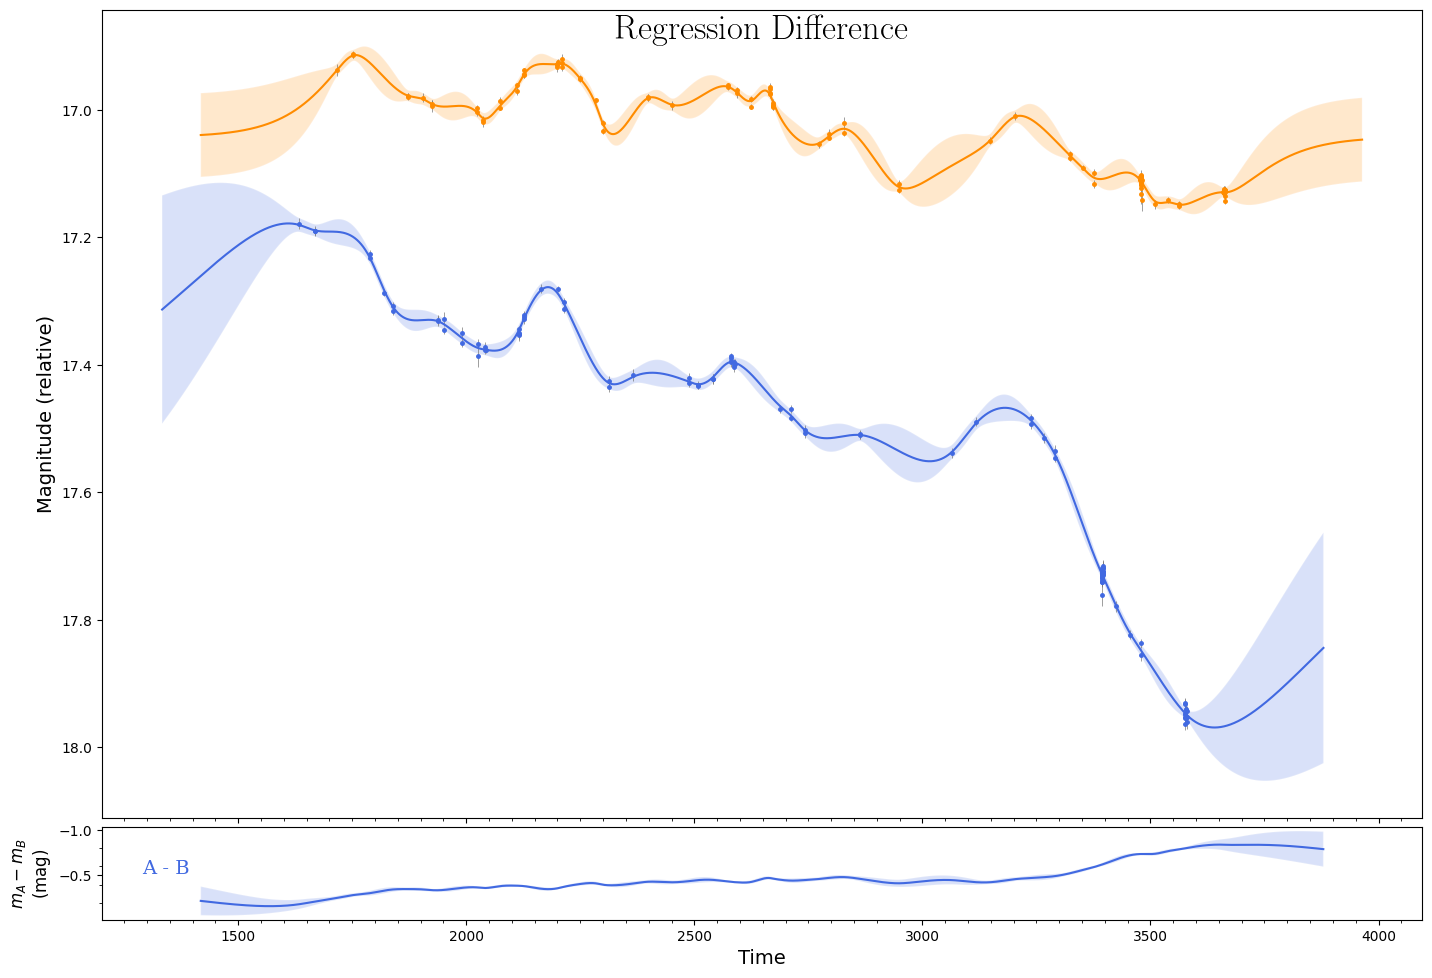

In [15]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

def plot_regdiff_panels(lcs, kwargs_reg, ref_idx=0, style="cosmograil_dr1",
                        figsize=(15, 10), savepath=None):
    """
    Plot:
      - top: light curves + regdiff regression
      - bottom: residual curves (ref - others), one panel per other curve

    Parameters
    ----------
    lcs : list
        List of pycs3 light curves (already time-shifted if desired).
    kwargs_reg : dict
        Must contain keys: pd, covkernel, pow, amp, scale, errscale.
    ref_idx : int
        Index of the reference curve (default 0).
    style : str
        pycs3 plotting style (default "cosmograil_dr1").
    savepath : str or None
        If provided, saves the figure to this path.
    """
    if len(lcs) < 2:
        raise ValueError("Need at least 2 light curves to compute residuals.")
    if not (0 <= ref_idx < len(lcs)):
        raise ValueError(f"ref_idx={ref_idx} out of range for {len(lcs)} light curves.")

    # Build regression-based light curves (rslc)
    myrslcs = [
        pycs3.regdiff.rslc.factory(
            l,
            pd=kwargs_reg["pd"],
            covkernel=kwargs_reg["covkernel"],
            pow=kwargs_reg["pow"],
            amp=kwargs_reg["amp"],
            scale=kwargs_reg["scale"],
            errscale=kwargs_reg["errscale"],
        )
        for l in lcs
    ]

    # Residuals: ref - others
    residuals = []
    for i in range(len(lcs)):
        if i == ref_idx:
            continue
        res = pycs3.regdiff.rslc.subtract(myrslcs[ref_idx], myrslcs[i])
        res.plotcolour = lcs[i].plotcolour  
        residuals.append((i, res))

    # Figure layout: 8 rows main + 1 row per residual
    n_res = len(residuals)
    fig = plt.figure(figsize=figsize)
    gs = gridspec.GridSpec(8 + n_res, 1, figure=fig)
    fig.subplots_adjust(left=0.08, right=0.96, top=0.98, bottom=0.07, hspace=0.10)

    ax_main = fig.add_subplot(gs[:8, 0])
    ax_res = [fig.add_subplot(gs[8+k, 0], sharex=ax_main) for k in range(n_res)]

    # Main panel
    pycs3.gen.lc_func.display(
        lcs, myrslcs,
        showdelays=False, showlegend=False,
        title=r"$\mathrm{Regression\ Difference}$",
        filename="screen", ax=ax_main, style=style
    )
    ax_main.tick_params(labelbottom=False)

    ref_name = lcs[ref_idx].object

    # Residual panels
    for k, (i, res) in enumerate(residuals):
        other_name = lcs[i].object
        text = [(0.03, 0.5, f"{ref_name} - {other_name}",
                 {"fontsize": 14, "color": lcs[i].plotcolour})]

        pycs3.gen.lc_func.display(
            [], [res],
            showdelays=False, showlegend=False,
            filename="screen", ax=ax_res[k], style=style,
            text=text
        )

        ax_res[k].set_ylabel(
            rf"$m_{{{ref_name}}} - m_{{{other_name}}}$" "\n" r"$\mathrm{(mag)}$",
            fontsize=12
        )

        if k < n_res - 1:
            ax_res[k].tick_params(labelbottom=False)

    ax_res[-1].set_xlabel("Time") 

    if savepath:
        fig.savefig(savepath, dpi=200, bbox_inches="tight")

    return fig, ax_main, ax_res

plot_regdiff_panels(lcs, kwargs_reg)